# Teacher-student network
In this approcah a synthetic dataset is created by a teacher network, then noise is added to the inputs to make the classification task more difficult for the student network to learn.

## MNIST NN

In [140]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
# Set the seeds for reproducibility
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)

LAYERS = (20, 50, 50, 50, 10)

In [117]:
# Neural network creator

class TeacherNetwork(nn.Module):

    # Pass the hidden layer sizes as a tuple (NOT as a list or a int: if only one pass it as (10,))
    def __init__(self, input_size, layers, act = nn.Tanh()):
    
        super().__init__()  #Initialize upper modules
        
        # Module list (creates a list of modules that are seen from the library)
        # DO NOT USE A LIST (it is not tracked by torch when weights are updated)

        self.N_features = (input_size, *layers)
        self.N_hidden = len(layers)
        self.linears = nn.ModuleList([nn.Linear(self.N_features[i], self.N_features[i+1]) for i in range(self.N_hidden)])

        self.act = act
        self.out_act = nn.Sigmoid()

        self.out_layer = nn.Linear(in_features=self.N_features[-1], out_features=1)

    def forward(self, x):
    
        for layer in self.linears:
            a = layer(x)
            x = self.act(a)

        out = self.out_layer(a)
        out = self.out_act(out)
        # Return the label
        return out


In [133]:
teacher = TeacherNetwork(input_size=20, layers=(50,80,40,20,20))

In [146]:
x = np.random.normal(size = (100000,20)).astype(np.float32)

In [147]:
with torch.no_grad():
    probs = teacher(torch.from_numpy(x))

# Convert the probabilities to numpy
probs = probs.detach().numpy().flatten()

treshold = np.median(probs)
labels = (probs > treshold).astype(int)

In [148]:
dataset = TensorDataset(torch.from_numpy(x), torch.from_numpy(labels))

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(0))

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [149]:
# Neural network creator

class NeuralNetwork(nn.Module):

    # Pass the hidden layer sizes as a tuple (NOT as a list or a int: if only one pass it as (10,))
    def __init__(self, Nh, Ni=784, No=10, act = nn.Tanh()):
    
        super().__init__()  #Initialize upper modules
        
        self.Nh = Nh
        self.No = No
        
        self.N_hidden = len(Nh)         # Number of hidden layers
        self.N_features = (Ni, *Nh) 
        self.layer_names = [f'{len}' for len in self.Nh]

        # Module list (creates a list of modules that are seen from the library)
        # DO NOT USE A LIST (it is not tracked by torch when weights are updated)
        self.linears = nn.ModuleList([nn.Linear(self.N_features[i], self.N_features[i+1]) for i in range(self.N_hidden)])

        self.act = act

        self.out_layer = nn.Linear(in_features=self.N_features[-1], out_features=No)

        # Save the loss history and the accuracy as variables of the network
        self.train_loss = []
        self.test_loss = []

        self.train_acc = []
        self.test_acc = []

    # This is a custom forward function that also explicitly returns the hidden variables as a tuple h
    def forward(self, x, return_hidden = False):
        # Hidden variables
        h = {}
        for layer, layer_name in zip(self.linears, self.layer_names):
            a = layer(x)
            x = self.act(a)
            # Save the activations
            if return_hidden:
                h[layer_name] = x

        if return_hidden:
            return self.out_layer(x), {layer_name:h[layer_name].detach().cpu().numpy() for layer_name in h}
        
        return self.out_layer(x)


In [150]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NeuralNetwork(Ni=20, Nh = (30,15,10), No=2).to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


In [151]:
def train_model(model, loss_function, optimizer, train_loader, test_loader, folder_path = os.getcwd(), epochs=10, model_name='MNIST'):

    folder_name = f'{model_name}_{"_".join(model.layer_names)}'
    path = folder_path + '/' + folder_name
    os.mkdir(path)
    
    H_record = {key:[] for key in model.layer_names}

    # Reset the train and test loss records
    model.train_loss = []
    model.test_loss = []

    for epoch in range(epochs):
        # Enter training mode: all computations are recorded for backpropagation, dropout is applied
        model.train()
        train_loss = 0
        train_samples = 0
        train_correct_guess = 0

        # Compute the model for each minibatch
        for x, y in train_loader:

            # Send the batches to the device
            x, y = x.to(device), y.to(device)
            # Reset the gradients
            optimizer.zero_grad()
            pred_y = model(x)
            loss = loss_function(pred_y, y)
            # Record all the gradients for each computation
            loss.backward()
            # Apply Gradient descent
            optimizer.step()

            # Compute the loss for this minibatch
            train_loss += loss.item()

            # Compute the accuracy for this minibatch
            predictions = torch.argmax(pred_y, dim=1)
            train_correct_guess += (predictions == y).sum().item()
            train_samples += y.size(0)

        
        # Exit training mode
        model.eval()
        test_loss = 0.0
        
        test_samples = 0
        test_correct_guess = 0
        
        # Create an empty ndarray to use for concatenating the hidden variables for each minibatch
        H_epoch = {f'{layer_size}':np.empty(shape=(0,layer_size))  for layer_size in model.Nh}
        
        # Stop tracking the gradients
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                # Test the model
                pred_y, H_batch = model(x, return_hidden=True)

                for key in model.layer_names:
                    H_epoch[key] = np.concatenate((H_epoch[key], H_batch[key]), axis=0)

                loss = loss_function(pred_y,y)

                test_loss += loss

                predictions = torch.argmax(pred_y, dim=1)
                test_correct_guess += (predictions == y).sum().item()
                test_samples += y.size(0)
    
        train_acc = train_correct_guess/train_samples
        test_acc = test_correct_guess/test_samples

        model.train_loss.append(train_loss)
        model.test_loss.append(test_loss)

        model.train_acc.append(train_acc)
        model.test_acc.append(test_acc)

        for key in model.layer_names:
            H_record[key].append(H_epoch[key])

        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Test loss: {test_loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

    for key in model.layer_names:
        np.savez(path + '/' + key, *H_record[key])
    
    # Save also the true labels
    true_labels = []
    for _, y in test_loader:
        true_labels.append(y.cpu().numpy())

    true_labels = np.concatenate(true_labels, axis=0)

    # Save the true labels and the losses and accuracies
    np.savez(path + '/data', true_labels = true_labels, train_loss = np.array(model.train_loss), test_loss = np.array(model.test_loss), train_acc = np.array(model.train_acc), test_acc = np.array(model.test_acc))

In [152]:
train_model(model, loss_function, optimizer, train_loader, test_loader, epochs=2000)

Epoch [1/2000], Train Loss: 191.3340, Test loss: 39.2227, Train Acc: 0.7283, Test Acc: 0.8702
Epoch [2/2000], Train Loss: 112.9973, Test loss: 19.5989, Train Acc: 0.9191, Test Acc: 0.9471
Epoch [3/2000], Train Loss: 59.9846, Test loss: 12.0284, Train Acc: 0.9550, Test Acc: 0.9586
Epoch [4/2000], Train Loss: 41.6246, Test loss: 9.4624, Train Acc: 0.9603, Test Acc: 0.9597
Epoch [5/2000], Train Loss: 34.8816, Test loss: 8.4159, Train Acc: 0.9608, Test Acc: 0.9597
Epoch [6/2000], Train Loss: 32.0490, Test loss: 7.9572, Train Acc: 0.9610, Test Acc: 0.9604
Epoch [7/2000], Train Loss: 30.6808, Test loss: 7.7497, Train Acc: 0.9615, Test Acc: 0.9607
Epoch [8/2000], Train Loss: 30.0219, Test loss: 7.6425, Train Acc: 0.9611, Test Acc: 0.9607
Epoch [9/2000], Train Loss: 29.6454, Test loss: 7.5554, Train Acc: 0.9614, Test Acc: 0.9608
Epoch [10/2000], Train Loss: 29.4033, Test loss: 7.5575, Train Acc: 0.9616, Test Acc: 0.9606
Epoch [11/2000], Train Loss: 29.2583, Test loss: 7.4940, Train Acc: 0.9618

KeyboardInterrupt: 

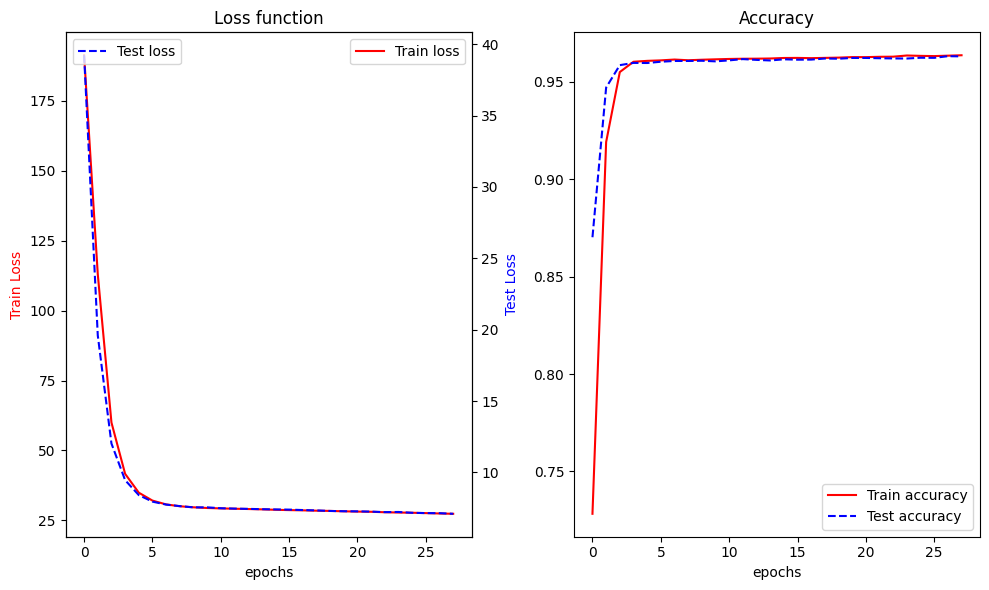

In [153]:
fig, (ax1, ax3) = plt.subplots(figsize=(10,6), ncols=2)

# Plot first dataset
ax1.plot(model.train_loss, 'r-', label='Train loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('Train Loss', color='r')

# Secondary axis sharing the same x-axis
ax2 = ax1.twinx()

# Automatically scale secondary y-axis to fit the second dataset
ax2.plot(model.test_loss, 'b--', label='Test loss')
ax2.set_ylabel('Test Loss', color='b')



ax1.set_title('Loss function')

ax3.plot(model.train_acc, 'r-', label='Train accuracy')
ax3.plot(model.test_acc, 'b--', label='Test accuracy')
ax3.set_xlabel('epochs')
ax3.set_title('Accuracy')

plt.tight_layout()
ax1.legend()
ax2.legend(loc = 'upper left')
ax3.legend()

plt.show()


## Mutual information computation

The model computation task is $Y \leftarrow X $ $ \rightarrow H_1 \rightarrow H_2 \rightarrow ... \rightarrow \hat Y $, where $X$ is the input, $Y$ the true labels and $\hat Y$ the reconstructed label predicted by the network. The mutula information used in Information Bottleneck is $I(X:H_i)$ and $I(Y:H)$, which is the mutual information contained in the Hidden variables w.r.t the input and the true labels distributions (NOT the predicted $\hat Y$, as they do not represent the true scope of the task). 

In the first case, $I(X:H_i) = H(H_i) - H(H_i|X) = H(H_i)$ because the variable $H_i$ _are deterministically derived_ by the inputs $X$ thanks to neural network.

In the second, $I(Y:H_i) = H(H_i) - H(H_i|Y)$ as $Y$ and $H_i$ are not deterministically linked. So to compute $H(H_i|Y)$ first the conditional probability must be computed (as $H(X|Y) = -\sum p(x,y)log(\frac{p(x,y)}{p(y)}) $). In the discretized case, this means that after binning $H_i$ for each input data $x_i$ ypu have to compute the corresponding bin $H_i$ and the corresponding label $y_i$, then computing the marginal distributions as $p(H_i|y_i)$

In [ ]:
#pip install infomeasure

### Kolchinsky upper bound
Considering the distribution as a mixture of gaussians centered around each point, the mutual information between the hidden variables and the input is given by $$ I(T;X) \leq -\frac{1}{P}\sum_i \log (\frac{1}{P}\sum_j \exp(-\frac{||h_i - h_j||^2}{2\sigma^2}))$$
and w.r.t the real labels Y is $$ I(T;Y) \leq -\frac{1}{P}\sum_i \log (\frac{1}{P}\sum_j \exp(-\frac{||h_i - h_j||^2}{2\sigma^2}))- \sum_l p_l[-\frac{1}{P_l}\sum_{i:Y_i=l} \log \frac{1}{P_l}\sum_{j, Y_l=j}\exp(-\frac{||h_i - h_j||^2}{2\sigma^2})]$$

To this mutual information there is also a lower bound given by $$ I(T;Y) \geq -\frac{1}{P}\sum_i \log (\frac{1}{P}\sum_j \exp(-\frac{||h_i - h_j||^2}{8\sigma^2}))- \sum_l p_l[-\frac{1}{P_l}\sum_{i:Y_i=l} \log \frac{1}{P_l}\sum_{j, Y_l=j}\exp(-\frac{||h_i - h_j||^2}{8\sigma^2})]$$

In [ ]:
# Binning function

def bin_values(x, bins):
    '''This function digitizes values and the counts the single unique values'''

def kolchinsky_h(h, sigma, mode='upper'):
    ''' COmputes the entropy upper bound using a gaussian KDE'''
    c = 2 if mode=='upper' else 8

    pairwise
    
    

In [ ]:
x = np.arange(0,10,1)

In [ ]:
np.sum(x**2)[:,None]

IndexError: invalid index to scalar variable.

In [ ]:
X = x
Y = x
X2 = np.sum(X**2, axis=1)[:, None]
Y2 = np.sum(Y**2, axis=1)[None, :]
D = np.sqrt(X2 + Y2 - 2 * X @ Y.T)


AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
# Compute the entropy of a known distribution

scale = 5
x = rng.normal(loc = 0, scale = scale, size=1000)

# The expected value is 1/2log(pi*e*2*sigma**2)
h_0 = 0.5*np.log(2*np.e*np.pi*scale**2)

h_kl = im.entropy(x, approach='kl', k=4)

print(h_0, h_kl)

plt.hist(x)

NameError: name 'im' is not defined

# The same in a multivariate distribution

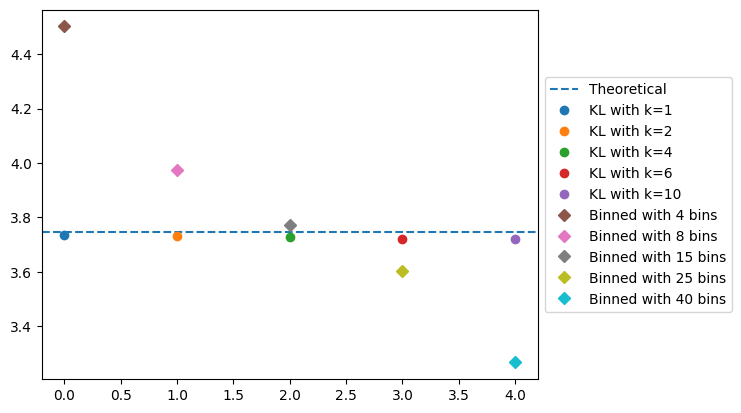

In [ ]:
C = np.array(((1, 0.5, -0.5), (0.5, 1, 0.2), (-0.5, 0.2, 1)))
x = rng.multivariate_normal([0, 0, 0], C, size=10000)

h_0 = 0.5*np.log((2*np.pi*np.e)**3*np.linalg.det(C))

plt.axhline(y=h_0, label='Theoretical', ls='--', xmin=0, xmax=5)
for i, k in enumerate([1,2,4,6,10]):
    plt.plot(i, im.entropy(x, approach='kl', k=k), 'o', label=(f'KL with k={k}'), )

for i, k in enumerate([4, 8 ,15,25, 40,]):
    f_i, bins = np.histogramdd(x, bins = k, density=False)
    bin_vol = (bins[0][1]-bins[0][0])*(bins[1][1]-bins[1][0])*(bins[2][1]-bins[2][0])
    p_i = f_i/np.sum(f_i)
    p_i = p_i[p_i>0]
    h_binned = -np.sum(p_i*np.log(p_i)) + np.log(bin_vol)
    plt.plot(i, h_binned, 'D', label=f'Binned with {k} bins')

plt.legend( loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.show()

# Computing the mutual information over the datasets

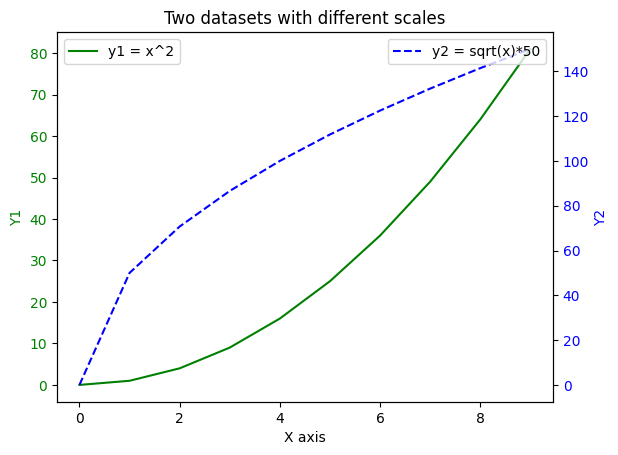

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
x = np.arange(0, 10, 1)
y1 = x ** 2          # first dataset
y2 = np.sqrt(x) * 50  # second dataset, different scale

# Create figure and first axis
fig, ax1 = plt.subplots()

# Plot first dataset
ax1.plot(x, y1, 'g-', label='y1 = x^2')
ax1.set_xlabel('X axis')
ax1.set_ylabel('Y1', color='g')
ax1.tick_params(axis='y', labelcolor='g')

# Secondary axis sharing the same x-axis
ax2 = ax1.twinx()

# Automatically scale secondary y-axis to fit the second dataset
ax2.plot(x, y2, 'b--', label='y2 = sqrt(x)*50')
ax2.set_ylabel('Y2', color='b')
ax2.tick_params(axis='y', labelcolor='b')

# Optional: legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title("Two datasets with different scales")
plt.show()
